# 4D-Lung Data Inspection and Experiment Preparation

This notebook provides a reproducible workflow for inspecting the 4D-Lung dataset, defining a working case, validating CT data, visualizing intermediate results, and preparing inputs for MedGS4D experiments.

The workflow includes:

1. verification of the PLGrid compute environment and project paths;
2. inspection of downloaded and extracted 4D-Lung data;
3. selection of a patient, study, respiratory phase, and CT series;
4. validation of DICOM metadata, slice geometry, orientation, and ordering;
5. visualization of representative grayscale CT slices using a fixed HU window;
6. preparation of an alternating train/test split;
7. export of the resolved case configuration and reproducible split manifest.

## Execution model

JupyterLab is displayed in a web browser on the local computer, but the Python kernel and all computations run on a PLGrid GH200 worker.

The notebook file may be downloaded to the local computer and uploaded through the JupyterLab interface. Collaborators therefore do not need write access to the shared project repository.

Each user maintains:

- a private copy of the source repositories;
- a private Python environment;
- a private Jupyter authentication token;
- a writable directory for notebooks, logs, and experiment results.

The shared 4D-Lung data remain in the project owner's storage and are accessed in read-only mode.

## Paths used in this instruction

Replace `<PROJECT_OWNER_LOGIN>` with the login of the user who owns the shared MedGS4D data.

The current user's own login is obtained automatically from the `$USER` environment variable.

```bash
PROJECT_OWNER="<PROJECT_OWNER_LOGIN>"

SHARED_PROJECT_ROOT="/net/storage/pr3/plgrid/plggtriplane/${PROJECT_OWNER}/medgs4d"
USER_PROJECT_ROOT="/net/storage/pr3/plgrid/plggtriplane/${USER}/medgs4d"
```

The two locations have different purposes:

```text
SHARED_PROJECT_ROOT
├── data/                  shared 4D-Lung data
├── repo/medgs4d/          reference MedGS4D repository
└── repo/MedGS/            reference MedGS repository

USER_PROJECT_ROOT
├── repo/                  private repository copies
├── envs/                  private Python environments
├── notebooks/             uploaded or modified notebooks
├── results/               private experiment outputs
├── logs/                  private logs
└── cache/                 private package and build cache
```

# One-time user setup

The steps in this section are performed once by each collaborator.

## 1. Log in to Helios

Use the user's own PLGrid login:

```bash
ssh <YOUR_PLGRID_LOGIN>@login01.helios.cyfronet.pl
```

Define the shared and personal paths:

```bash
PROJECT_OWNER="<PROJECT_OWNER_LOGIN>"

SHARED_PROJECT_ROOT="/net/storage/pr3/plgrid/plggtriplane/${PROJECT_OWNER}/medgs4d"
USER_PROJECT_ROOT="/net/storage/pr3/plgrid/plggtriplane/${USER}/medgs4d"
```

Verify access to the shared project:

```bash
test -r "$SHARED_PROJECT_ROOT/repo/medgs4d/README.md"
test -r "$SHARED_PROJECT_ROOT/repo/MedGS/README.md"
test -d "$SHARED_PROJECT_ROOT/data/raw/dicom_by_series"

echo "Shared project access verified."
```

## 2. Create a private workspace

```bash
mkdir -p \
  "$USER_PROJECT_ROOT/repo" \
  "$USER_PROJECT_ROOT/envs" \
  "$USER_PROJECT_ROOT/notebooks" \
  "$USER_PROJECT_ROOT/results" \
  "$USER_PROJECT_ROOT/logs" \
  "$USER_PROJECT_ROOT/cache"
```

Restrict the personal workspace to the current user:

```bash
chmod 700 "$USER_PROJECT_ROOT"
```

## 3. Create private repository copies

Clone the shared MedGS4D repository:

```bash
if [[ ! -d "$USER_PROJECT_ROOT/repo/medgs4d/.git" ]]; then
  git clone \
    "$SHARED_PROJECT_ROOT/repo/medgs4d" \
    "$USER_PROJECT_ROOT/repo/medgs4d"
fi
```

Clone the shared MedGS repository, including the local GH200 compatibility changes:

```bash
if [[ ! -d "$USER_PROJECT_ROOT/repo/MedGS/.git" ]]; then
  git clone \
    "$SHARED_PROJECT_ROOT/repo/MedGS" \
    "$USER_PROJECT_ROOT/repo/MedGS"
fi
```

Initialize the MedGS submodules:

```bash
git -C "$USER_PROJECT_ROOT/repo/MedGS" \
  submodule update --init --recursive
```

Display the checked-out revisions:

```bash
git -C "$USER_PROJECT_ROOT/repo/medgs4d" \
  log -1 --oneline

git -C "$USER_PROJECT_ROOT/repo/MedGS" \
  log -1 --oneline
```

## 4. Request a GH200 worker for environment creation

The environment must be created on an ARM GH200 worker rather than on the x86-64 login node.

```bash
srun \
  --account=plgunhype-gpu-gh200 \
  --partition=plgrid-gpu-gh200 \
  --nodes=1 \
  --ntasks=1 \
  --cpus-per-task=8 \
  --mem=64G \
  --gres=gpu:1 \
  --time=04:00:00 \
  --pty bash -i
```

Wait until the worker prompt appears and verify the allocation:

```bash
hostname
uname -m
echo "$SLURM_JOB_ID"
```

The expected architecture is:

```text
aarch64
```

Do not continue while the hostname is `login01`.

## 5. Load the required system modules

Redefine the personal project path in the worker shell:

```bash
USER_PROJECT_ROOT="/net/storage/pr3/plgrid/plggtriplane/${USER}/medgs4d"
```

Load Python and CUDA:

```bash
module purge
module load Python/3.11.5
module load CUDA/12.8.0
```

Verify the modules:

```bash
python --version
nvcc --version
```

## 6. Create a private Python environment

Do not copy another user's virtual-environment directory. Create a new environment in the current user's workspace:

```bash
ENV_ROOT="$USER_PROJECT_ROOT/envs/medgs-gh200"

if [[ ! -x "$ENV_ROOT/bin/python" ]]; then
  python -m venv "$ENV_ROOT"
fi

source "$ENV_ROOT/bin/activate"
```

Configure the private package cache and build environment:

```bash
export PIP_CACHE_DIR="$USER_PROJECT_ROOT/cache/pip"
export TMPDIR="$USER_PROJECT_ROOT/cache/tmp"

mkdir -p "$PIP_CACHE_DIR" "$TMPDIR"

export CUDA_HOME="/net/software/aarch64/el9/CUDA/12.8.0"
export PATH="$CUDA_HOME/bin:$PATH"
export LD_LIBRARY_PATH="$CUDA_HOME/lib64:${LD_LIBRARY_PATH:-}"

export TORCH_CUDA_ARCH_LIST="9.0"
export MAX_JOBS="${SLURM_CPUS_PER_TASK:-8}"

export CC="/usr/bin/gcc"
export CXX="/usr/bin/g++"
export CUDAHOSTCXX="/usr/bin/g++"
export PYTHONNOUSERSITE=1
```

Upgrade the Python build tools:

```bash
python -m pip install --upgrade \
  pip \
  setuptools \
  wheel \
  ninja
```

Install the GH200-compatible PyTorch build:

```bash
python -m pip install \
  torch==2.7.1 \
  torchvision==0.22.1 \
  --index-url https://download.pytorch.org/whl/cu128
```

Install the data-processing, visualization, and Jupyter dependencies:

```bash
python -m pip install \
  numpy \
  pandas \
  matplotlib \
  pydicom \
  nibabel \
  scikit-image \
  opencv-python-headless \
  trimesh \
  tqdm \
  plyfile \
  jupyterlab \
  ipykernel \
  ipywidgets
```

## 7. Build the MedGS CUDA extensions

```bash
MEDGS_REPOSITORY="$USER_PROJECT_ROOT/repo/MedGS"
```

Install the differentiable Gaussian rasterizer:

```bash
python -m pip install \
  --no-build-isolation \
  "$MEDGS_REPOSITORY/submodules/diff-gaussian-rasterization"
```

Install `simple-knn`:

```bash
python -m pip install \
  --no-build-isolation \
  "$MEDGS_REPOSITORY/submodules/simple-knn"
```

Install `fused-ssim`:

```bash
python -m pip install \
  --no-build-isolation \
  "$MEDGS_REPOSITORY/submodules/fused-ssim"
```

## 8. Verify the private environment

```bash
python - <<'PY'
import platform

import matplotlib
import numpy
import pandas
import pydicom
import torch
import torchvision

import diff_gaussian_rasterization
import fused_ssim
import simple_knn

print("Architecture:", platform.machine())
print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA capability:", torch.cuda.get_device_capability(0))

assert platform.machine() == "aarch64"
assert torch.cuda.is_available()
assert torch.cuda.get_device_capability(0) == (9, 0)

print("Private MedGS4D environment validation passed.")
PY
```

## 9. Register the private Jupyter kernel

```bash
python -m ipykernel install \
  --user \
  --name "medgs-gh200-${USER}" \
  --display-name "MedGS GH200 (${USER})"
```

The environment setup is now complete.

Exit the setup worker:

```bash
deactivate
exit
```

# Starting a notebook session

The steps in this section are performed whenever the notebook is used.

## 1. Request an interactive GH200 worker

Log in to Helios and run:

```bash
srun \
  --account=plgunhype-gpu-gh200 \
  --partition=plgrid-gpu-gh200 \
  --nodes=1 \
  --ntasks=1 \
  --cpus-per-task=8 \
  --mem=64G \
  --gres=gpu:1 \
  --time=04:00:00 \
  --pty bash -i
```

Verify that the worker is active:

```bash
hostname
uname -m
echo "$SLURM_JOB_ID"
```

The architecture must be:

```text
aarch64
```

## 2. Activate the user's private environment

```bash
USER_PROJECT_ROOT="/net/storage/pr3/plgrid/plggtriplane/${USER}/medgs4d"
ENV_ROOT="$USER_PROJECT_ROOT/envs/medgs-gh200"

module purge
module load Python/3.11.5
module load CUDA/12.8.0

source "$ENV_ROOT/bin/activate"
```

Configure CUDA and the private cache:

```bash
export PIP_CACHE_DIR="$USER_PROJECT_ROOT/cache/pip"
export TMPDIR="$USER_PROJECT_ROOT/cache/tmp"

export CUDA_HOME="/net/software/aarch64/el9/CUDA/12.8.0"
export PATH="$CUDA_HOME/bin:$PATH"
export LD_LIBRARY_PATH="$CUDA_HOME/lib64:${LD_LIBRARY_PATH:-}"

export TORCH_CUDA_ARCH_LIST="9.0"
export MAX_JOBS="${SLURM_CPUS_PER_TASK:-8}"

export CC="/usr/bin/gcc"
export CXX="/usr/bin/g++"
export CUDAHOSTCXX="/usr/bin/g++"
export PYTHONNOUSERSITE=1
```

Verify that the correct Python environment is active:

```bash
which python
python --version
```

The Python path should point into:

```text
.../<YOUR_PLGRID_LOGIN>/medgs4d/envs/medgs-gh200/bin/python
```

## 3. Configure persistent Jupyter authentication

Each user stores a private token in their own home directory.

```bash
TOKEN_FILE="$HOME/.jupyter/medgs4d_token"

mkdir -p "$HOME/.jupyter"
chmod 700 "$HOME/.jupyter"

if [[ ! -s "$TOKEN_FILE" ]]; then
  (
    umask 077

    python - <<'PY'
from pathlib import Path
import secrets

token_path = Path.home() / ".jupyter" / "medgs4d_token"
token_path.write_text(secrets.token_hex(32), encoding="ascii")
PY
  )
fi

chmod 600 "$TOKEN_FILE"

export JUPYTER_TOKEN="$(tr -d '\r\n' < "$TOKEN_FILE")"
```

Validate the token:

```bash
python - <<'PY'
import os

token = os.environ.get("JUPYTER_TOKEN", "")

print("Token length:", len(token))
print("Contains whitespace:", any(character.isspace() for character in token))

assert len(token) == 64
assert not any(character.isspace() for character in token)

print("Token validation passed.")
PY
```

The expected result is:

```text
Token length: 64
Contains whitespace: False
Token validation passed.
```

Do not commit or share the token.

## 4. Start JupyterLab

Record the worker hostname:

```bash
WORKER_HOSTNAME="$(hostname -s)"

echo "Worker hostname: $WORKER_HOSTNAME"
```

Print the local browser address:

```bash
printf 'http://localhost:8888/lab?token=%s\n' "$JUPYTER_TOKEN"
```

Start JupyterLab in the user's private workspace:

```bash
jupyter lab \
  --no-browser \
  --ip=0.0.0.0 \
  --port=8888 \
  --ServerApp.port_retries=0 \
  --ServerApp.root_dir="$USER_PROJECT_ROOT"
```

Keep the worker terminal open.

## 5. Create the SSH tunnel from the local computer

On the local computer, open a separate terminal.

```bash
ssh -N \
  -o ExitOnForwardFailure=yes \
  -o ServerAliveInterval=60 \
  -L 8888:<WORKER_HOSTNAME>:8888 \
  <YOUR_PLGRID_LOGIN>@login01.helios.cyfronet.pl
```

Example structure:

```bash
ssh -N \
  -o ExitOnForwardFailure=yes \
  -o ServerAliveInterval=60 \
  -L 8888:x1002c1s3b1n0:8888 \
  <YOUR_PLGRID_LOGIN>@login01.helios.cyfronet.pl
```

Keep the tunnel running.

Open the URL printed before JupyterLab was started:

```text
http://localhost:8888/lab?token=<PERSISTENT_TOKEN>
```

## 6. Upload the notebook from the local computer

In the JupyterLab file browser:

1. open the `notebooks` directory;
2. click the **Upload Files** button;
3. select the local `.ipynb` file;
4. open the uploaded notebook;
5. select the kernel named:

```text
MedGS GH200 (<YOUR_PLGRID_LOGIN>)
```

The notebook interface is displayed locally, but its Python code executes on the allocated PLGrid worker.

## 7. Configure shared input and private output paths

The notebook should use two separate roots:

```python
SHARED_PROJECT_ROOT = Path(
    "/net/storage/pr3/plgrid/plggtriplane/"
    "<PROJECT_OWNER_LOGIN>/medgs4d"
)

USER_PROJECT_ROOT = Path(
    "/net/storage/pr3/plgrid/plggtriplane"
) / os.environ["USER"] / "medgs4d"
```

Use the shared root for read-only inputs:

```text
SHARED_PROJECT_ROOT/data/raw/series_zips
SHARED_PROJECT_ROOT/data/raw/dicom_by_series
SHARED_PROJECT_ROOT/data/metadata
```

Use the private root for generated artifacts:

```text
USER_PROJECT_ROOT/results
USER_PROJECT_ROOT/logs
USER_PROJECT_ROOT/cache
```

Do not write generated results into the shared project owner's directory.

# Stopping the session

Stop JupyterLab in the worker terminal:

```text
Ctrl+C
```

Confirm shutdown when requested.

Exit the worker shell:

```bash
deactivate
exit
```

Stop the local SSH tunnel:

```text
Ctrl+C
```

The interactive Slurm allocation ends when the worker shell exits.

# Updating the private repository copies

Updates can be pulled from the shared reference repositories.

On `login01`:

```bash
PROJECT_OWNER="<PROJECT_OWNER_LOGIN>"

SHARED_PROJECT_ROOT="/net/storage/pr3/plgrid/plggtriplane/${PROJECT_OWNER}/medgs4d"
USER_PROJECT_ROOT="/net/storage/pr3/plgrid/plggtriplane/${USER}/medgs4d"
```

Update MedGS4D:

```bash
git -C "$USER_PROJECT_ROOT/repo/medgs4d" \
  pull "$SHARED_PROJECT_ROOT/repo/medgs4d"
```

Update MedGS:

```bash
git -C "$USER_PROJECT_ROOT/repo/MedGS" \
  pull "$SHARED_PROJECT_ROOT/repo/MedGS"

git -C "$USER_PROJECT_ROOT/repo/MedGS" \
  submodule update --init --recursive
```

# Rotating the Jupyter token

To invalidate the current token:

```bash
rm -f "$HOME/.jupyter/medgs4d_token"
unset JUPYTER_TOKEN
```

A new token will be generated during the next notebook session.

In [3]:
import sys

print(sys.executable)

/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/envs/medgs-gh200/bin/python


In [2]:
from __future__ import annotations

import json
import os
import platform
import re
import socket
import subprocess
import sys
from pathlib import Path
from typing import Any, Sequence

import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pydicom
import torch
from IPython.display import display
from pydicom.dataset import Dataset

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_rows", 500)

## 1. Project paths and runtime environment

Shared inputs are read from the project owner's storage. Generated artifacts are written to the current user's workspace.

In [34]:
print("Defining shared input paths and the current user's output paths.")

STORAGE_ROOT = Path("/net/storage/pr3/plgrid/plggtriplane")
PROJECT_OWNER_LOGIN = "plgmozo"

SHARED_PROJECT_ROOT = STORAGE_ROOT / PROJECT_OWNER_LOGIN / "medgs4d"
USER_PROJECT_ROOT = STORAGE_ROOT / os.environ["USER"] / "medgs4d"

SERIES_ZIPS_ROOT = SHARED_PROJECT_ROOT / "data" / "raw" / "series_zips"
DICOM_ROOT = SHARED_PROJECT_ROOT / "data" / "raw" / "dicom_by_series"
METADATA_ROOT = SHARED_PROJECT_ROOT / "data" / "metadata"
RESULTS_ROOT = USER_PROJECT_ROOT / "results"
LOGS_ROOT = USER_PROJECT_ROOT / "logs"
REPOSITORIES_ROOT = SHARED_PROJECT_ROOT / "repo"
ENVIRONMENTS_ROOT = SHARED_PROJECT_ROOT / "envs"
SHARED_RESULTS_ROOT = SHARED_PROJECT_ROOT / "results"
SHARED_LOGS_ROOT = SHARED_PROJECT_ROOT / "logs"
CASES_ROOT = RESULTS_ROOT / "prepared_cases"

required_paths = [
    SHARED_PROJECT_ROOT,
    SERIES_ZIPS_ROOT,
    DICOM_ROOT,
    USER_PROJECT_ROOT,
]

missing_paths = [path for path in required_paths if not path.is_dir()]
if missing_paths:
    raise FileNotFoundError(
        "Required directories are missing:\n"
        + "\n".join(str(path) for path in missing_paths)
    )

path_table = pd.DataFrame(
    [
        {"Purpose": "Shared project", "Path": SHARED_PROJECT_ROOT},
        {"Purpose": "Series ZIPs", "Path": SERIES_ZIPS_ROOT},
        {"Purpose": "Extracted DICOM", "Path": DICOM_ROOT},
        {"Purpose": "User workspace", "Path": USER_PROJECT_ROOT},
        {"Purpose": "User results", "Path": RESULTS_ROOT},
    ]
)
display(path_table)

Defining shared input paths and the current user's output paths.


,Purpose,Path
0,Shared project,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d
1,Series ZIPs,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/data/raw/series_zips
2,Extracted DICOM,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/data/raw/dicom_by_series
3,User workspace,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d
4,User results,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/results


In [5]:
print("Checking the PLGrid worker, Python environment, CUDA, and GPU.")


def run_command(command: Sequence[str]) -> str:
    """Run a diagnostic command and return its standard output."""

    result = subprocess.run(
        list(command),
        check=True,
        capture_output=True,
        text=True,
    )
    return result.stdout.strip()


environment_report = pd.DataFrame(
    [
        {"Check": "Hostname", "Value": socket.gethostname()},
        {"Check": "Architecture", "Value": platform.machine()},
        {"Check": "Python executable", "Value": sys.executable},
        {"Check": "Python version", "Value": sys.version.split()[0]},
        {"Check": "SLURM job ID", "Value": os.environ.get("SLURM_JOB_ID", "")},
        {"Check": "PyTorch version", "Value": torch.__version__},
        {"Check": "CUDA available", "Value": torch.cuda.is_available()},
        {
            "Check": "GPU",
            "Value": (
                torch.cuda.get_device_name(0)
                if torch.cuda.is_available()
                else ""
            ),
        },
        {
            "Check": "nvidia-smi",
            "Value": run_command(
                [
                    "nvidia-smi",
                    "--query-gpu=name,memory.total",
                    "--format=csv,noheader",
                ]
            ),
        },
    ]
)
display(environment_report)

if platform.machine() != "aarch64":
    raise RuntimeError("The notebook must run on an aarch64 GH200 worker.")

if not os.environ.get("SLURM_JOB_ID"):
    raise RuntimeError("No active Slurm allocation was detected.")

if not torch.cuda.is_available():
    raise RuntimeError("CUDA is not available in the active Python environment.")

Checking the PLGrid worker, Python environment, CUDA, and GPU.


,Check,Value
0,Hostname,x1002c6s5b0n0
1,Architecture,aarch64
2,Python executable,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/envs/medgs-gh200/bin/python
3,Python version,3.11.5
4,SLURM job ID,19649036
5,PyTorch version,2.7.1+cu128
6,CUDA available,True
7,GPU,NVIDIA GH200 120GB
8,nvidia-smi,"NVIDIA GH200 120GB, 97871 MiB"


## 2. Available data

First inspect the extracted patients. The patient used in the experiment is selected explicitly in the following section.

In [11]:
print("Summarizing project storage and counting downloaded and extracted data.")

def directory_size_bytes(path: Path) -> int:
    """Return the apparent size of a directory in bytes."""

    result = subprocess.run(
        ["du", "-sb", str(path)],
        check=True,
        capture_output=True,
        text=True,
    )
    return int(result.stdout.split(maxsplit=1)[0])


def count_matching_files(root: Path, pattern: str) -> int:
    """Count recursively all files matching a filename pattern."""

    result = subprocess.run(
        [
            "find",
            str(root),
            "-type",
            "f",
            "-name",
            pattern,
            "-printf",
            ".",
        ],
        check=True,
        capture_output=True,
    )
    return len(result.stdout)


def format_gib(size_bytes: int) -> str:
    """Format a byte count in gibibytes."""

    return f"{size_bytes / (1024 ** 3):.2f} GiB"


inventory_paths = [
    ("Project root", SHARED_PROJECT_ROOT),
    ("Downloaded series ZIPs", SERIES_ZIPS_ROOT),
    ("Extracted DICOM series", DICOM_ROOT),
    ("Metadata", METADATA_ROOT),
    ("Results", RESULTS_ROOT),
    ("Repositories", SHARED_PROJECT_ROOT / "repo"),
    ("Logs", LOGS_ROOT),
]

inventory_rows = []

for label, path in inventory_paths:
    exists = path.exists()

    inventory_rows.append(
        {
            "Item": label,
            "Path": str(path),
            "Exists": exists,
            "Approximate size": (
                format_gib(directory_size_bytes(path))
                if exists
                else "-"
            ),
        }
    )

inventory_df = pd.DataFrame(inventory_rows)

zip_count = count_matching_files(SERIES_ZIPS_ROOT, "*.zip")
dcm_count = count_matching_files(DICOM_ROOT, "*.dcm")

print(f"ZIP archives found: {zip_count:,}")
print(f"Extracted DICOM files found: {dcm_count:,}")

display(inventory_df)

Summarizing project storage and counting downloaded and extracted data.
ZIP archives found: 6,690
Extracted DICOM files found: 347,330


,Item,Path,Exists,Approximate size
0,Project root,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d,True,272.73 GiB
1,Downloaded series ZIPs,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/data/raw/series_zips,True,93.29 GiB
2,Extracted DICOM series,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/data/raw/dicom_by_series,True,170.52 GiB
3,Metadata,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/data/metadata,True,0.01 GiB
4,Results,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/results,True,0.01 GiB
5,Repositories,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/repo,True,0.25 GiB
6,Logs,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/logs,True,0.00 GiB


In [12]:
print("Listing downloaded archives and extracted patient directories.")


def count_series_directories(patient_dir: Path) -> int:
    """Count immediate DICOM series directories for one patient."""

    return sum(
        1
        for path in patient_dir.iterdir()
        if path.is_dir() and not path.name.startswith(".")
    )


patient_directories = sorted(
    path
    for path in DICOM_ROOT.iterdir()
    if path.is_dir() and not path.name.startswith(".")
)

if not patient_directories:
    raise RuntimeError(f"No extracted patients were found in {DICOM_ROOT}.")

patients_df = pd.DataFrame(
    [
        {
            "PatientID": patient_dir.name,
            "Series directories": count_series_directories(patient_dir),
            "Path": str(patient_dir),
        }
        for patient_dir in patient_directories
    ]
)

archive_count = sum(1 for path in SERIES_ZIPS_ROOT.glob("*/*.zip"))
extracted_series_count = int(patients_df["Series directories"].sum())

print(f"ZIP archives: {archive_count:,}")
print(f"Extracted patients: {len(patients_df):,}")
print(f"Extracted series directories: {extracted_series_count:,}")
display(patients_df)

Listing downloaded archives and extracted patient directories.
ZIP archives: 6,690
Extracted patients: 20
Extracted series directories: 6,690


,PatientID,Series directories,Path
0,100_HM10395,350,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/data/raw/dicom_by_series/100_HM10395
1,101_HM10395,120,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/data/raw/dicom_by_series/101_HM10395
2,102_HM10395,180,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/data/raw/dicom_by_series/102_HM10395
3,103_HM10395,390,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/data/raw/dicom_by_series/103_HM10395
4,104_HM10395,330,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/data/raw/dicom_by_series/104_HM10395
5,105_HM10395,350,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/data/raw/dicom_by_series/105_HM10395
6,106_HM10395,330,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/data/raw/dicom_by_series/106_HM10395
7,107_HM10395,290,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/data/raw/dicom_by_series/107_HM10395
8,108_HM10395,330,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/data/raw/dicom_by_series/108_HM10395
9,109_HM10395,380,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/data/raw/dicom_by_series/109_HM10395


## 3. Select a patient

Set `PATIENT_ID` to one of the identifiers displayed above.

In [13]:
print("Selecting the patient whose DICOM series will be inspected.")

PATIENT_ID = "112_HM10395"

patient_dir = DICOM_ROOT / PATIENT_ID
if not patient_dir.is_dir():
    available = ", ".join(patients_df["PatientID"].astype(str))
    raise FileNotFoundError(
        f"Patient directory not found: {patient_dir}\n"
        f"Available patients: {available}"
    )

print(f"Selected patient: {PATIENT_ID}")
print(f"Patient directory: {patient_dir}")

Selecting the patient whose DICOM series will be inspected.
Selected patient: 112_HM10395
Patient directory: /net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/data/raw/dicom_by_series/112_HM10395


## 4. Inspect the patient's DICOM series

One representative DICOM header is read from each series. Set the respiratory phase explicitly and inspect the resulting CT candidates.

In [14]:
print("Reading one DICOM header per series and listing CT candidates.")

TARGET_PHASE_PERCENT = 20.0
PHASE_PATTERN = re.compile(r"(\d+(?:\.\d+)?)\s*%")


def parse_phase_percent(description: str) -> float:
    """Extract the respiratory phase percentage or return NaN."""

    match = PHASE_PATTERN.search(description)
    return float(match.group(1)) if match else float("nan")


def list_dicom_files(series_dir: Path) -> list[Path]:
    """Return sorted DICOM files stored directly in a series directory."""

    return sorted(path for path in series_dir.glob("*.dcm") if path.is_file())


def inspect_series(patient_directory: Path) -> pd.DataFrame:
    """Read one representative header from every DICOM series."""

    records: list[dict[str, Any]] = []

    series_directories = sorted(
        path
        for path in patient_directory.iterdir()
        if path.is_dir() and not path.name.startswith(".")
    )

    for series_dir in series_directories:
        dicom_files = list_dicom_files(series_dir)
        if not dicom_files:
            raise RuntimeError(f"No DICOM files found in {series_dir}.")

        dataset = pydicom.dcmread(
            str(dicom_files[0]),
            stop_before_pixels=True,
            force=True,
        )
        description = str(getattr(dataset, "SeriesDescription", ""))

        records.append(
            {
                "PatientID": str(getattr(dataset, "PatientID", "")),
                "StudyDate": str(getattr(dataset, "StudyDate", "")),
                "StudyDescription": str(
                    getattr(dataset, "StudyDescription", "")
                ),
                "StudyInstanceUID": str(
                    getattr(dataset, "StudyInstanceUID", "")
                ),
                "Modality": str(getattr(dataset, "Modality", "")),
                "PhasePercent": parse_phase_percent(description),
                "SeriesNumber": getattr(dataset, "SeriesNumber", ""),
                "SeriesDescription": description,
                "SeriesInstanceUID": str(
                    getattr(dataset, "SeriesInstanceUID", "")
                ),
                "DICOM files": len(dicom_files),
                "Series path": str(series_dir),
            }
        )

    frame = pd.DataFrame(records)
    if frame.empty:
        raise RuntimeError(
            f"No readable DICOM series found in {patient_directory}."
        )

    return frame.sort_values(
        [
            "StudyDate",
            "StudyInstanceUID",
            "Modality",
            "PhasePercent",
            "SeriesNumber",
        ],
        na_position="last",
    ).reset_index(drop=True)


series_df = inspect_series(patient_dir)

ct_candidates_df = series_df.loc[
    (series_df["Modality"] == "CT")
    & np.isclose(
        series_df["PhasePercent"].astype(float),
        TARGET_PHASE_PERCENT,
        equal_nan=False,
    )
    ].copy()

if ct_candidates_df.empty:
    available_phases = sorted(
        series_df.loc[
            series_df["Modality"] == "CT",
            "PhasePercent",
        ]
        .dropna()
        .unique()
        .tolist()
    )
    raise RuntimeError(
        f"No CT series found for phase {TARGET_PHASE_PERCENT:g}%. "
        f"Available CT phases: {available_phases}"
    )

ct_candidates_df = (
    ct_candidates_df.sort_values(
        ["StudyDate", "StudyInstanceUID", "DICOM files", "SeriesInstanceUID"],
        ascending=[True, True, False, True],
    )
    .reset_index(drop=True)
    .reset_index(names="CandidateID")
)

print(
    f"CT candidates for patient {PATIENT_ID} "
    f"and phase {TARGET_PHASE_PERCENT:g}%: {len(ct_candidates_df)}"
)
display(
    ct_candidates_df[
        [
            "CandidateID",
            "StudyDate",
            "StudyDescription",
            "StudyInstanceUID",
            "SeriesNumber",
            "SeriesDescription",
            "DICOM files",
            "SeriesInstanceUID",
        ]
    ]
)

Reading one DICOM header per series and listing CT candidates.
CT candidates for patient 112_HM10395 and phase 20%: 40


,CandidateID,StudyDate,StudyDescription,StudyInstanceUID,SeriesNumber,SeriesDescription,DICOM files,SeriesInstanceUID
0,0,19991020,p4,1.3.6.1.4.1.14519.5.2.1.6834.5010.227360796846485012938078834722,1,"P4^P112^S301^I00005, Gated, 20.0%",118,1.3.6.1.4.1.14519.5.2.1.6834.5010.297748694875834220638469129147
1,1,19991115,p4,1.3.6.1.4.1.14519.5.2.1.6834.5010.229128625296481330856358422210,502,"P4^P112^S105^I0, Gated, 20.0%",50,1.3.6.1.4.1.14519.5.2.1.6834.5010.130267994757200739904106485029
2,2,19991115,p4,1.3.6.1.4.1.14519.5.2.1.6834.5010.319021555931788586696591718073,502,"P4^P112^S100^I0, Gated, 20.0%",50,1.3.6.1.4.1.14519.5.2.1.6834.5010.152480025872515953218702039441
3,3,19991116,p4,1.3.6.1.4.1.14519.5.2.1.6834.5010.149838038355570718718041648825,502,"P4^P112^S102^I0, Gated, 20.0%",50,1.3.6.1.4.1.14519.5.2.1.6834.5010.532181991977926908293781378186
4,4,19991116,p4,1.3.6.1.4.1.14519.5.2.1.6834.5010.200801864931866439652612223920,502,"P4^P112^S107^I0, Gated, 20.0%",50,1.3.6.1.4.1.14519.5.2.1.6834.5010.158410889480626006466266939699
5,5,19991116,p4,1.3.6.1.4.1.14519.5.2.1.6834.5010.219069727527719174421824832134,502,"P4^P112^S101^I0, Gated, 20.0%",50,1.3.6.1.4.1.14519.5.2.1.6834.5010.548536736998942652392304313888
6,6,19991116,p4,1.3.6.1.4.1.14519.5.2.1.6834.5010.335544213130778097645723258256,502,"P4^P112^S106^I0, Gated, 20.0%",50,1.3.6.1.4.1.14519.5.2.1.6834.5010.161202518955092190423065845726
7,7,19991117,p4,1.3.6.1.4.1.14519.5.2.1.6834.5010.111356820051240995392088140975,502,"P4^P112^S108^I0, Gated, 20.0%",50,1.3.6.1.4.1.14519.5.2.1.6834.5010.732934579481157804165450322423
8,8,19991117,p4,1.3.6.1.4.1.14519.5.2.1.6834.5010.169326662147228014419508103318,502,"P4^P112^S103^I0, Gated, 20.0%",50,1.3.6.1.4.1.14519.5.2.1.6834.5010.241573921920775384364080998569
9,9,19991122,p4,1.3.6.1.4.1.14519.5.2.1.6834.5010.165582776528137202025011114004,502,"P4^P112^S109^I0, Gated, 20.0%",50,1.3.6.1.4.1.14519.5.2.1.6834.5010.354587503149467771797000683707


## 5. Select the working case

Set `CT_SERIES_CANDIDATE_ID` to one of the candidate identifiers displayed above. The case name, HU window, and artifact export are also defined explicitly here.

In [24]:
print("Selecting one CT series and defining the working experiment case.")

CT_SERIES_CANDIDATE_ID = 23
CASE_NAME = "single_phase_ct_every_second_slice_v1"
HU_WINDOW_LOW = -1000.0
HU_WINDOW_HIGH = 400.0
EXPORT_ARTIFACTS = True


def format_dicom_date(value: str) -> str:
    """Convert a DICOM YYYYMMDD date to ISO YYYY-MM-DD format."""

    value = str(value)

    if re.fullmatch(r"\d{8}", value):
        return f"{value[:4]}-{value[4:6]}-{value[6:8]}"

    return value or "unknown"


selected_rows = ct_candidates_df.loc[
    ct_candidates_df["CandidateID"] == CT_SERIES_CANDIDATE_ID
]

if len(selected_rows) != 1:
    available_ids = ct_candidates_df["CandidateID"].tolist()
    raise RuntimeError(
        f"Candidate {CT_SERIES_CANDIDATE_ID} was not found. "
        f"Available candidate IDs: {available_ids}"
    )

selected_series = selected_rows.iloc[0]

selected_study_date_raw = str(selected_series["StudyDate"])
selected_study_date = format_dicom_date(selected_study_date_raw)
selected_study_description = str(selected_series["StudyDescription"])
selected_study_uid = str(selected_series["StudyInstanceUID"])

selected_series_number = selected_series["SeriesNumber"]
selected_series_description = str(selected_series["SeriesDescription"])
selected_series_uid = str(selected_series["SeriesInstanceUID"])
selected_series_dir = Path(selected_series["Series path"])
selected_slice_count = int(selected_series["DICOM files"])
selected_phase_percent = float(selected_series["PhasePercent"])

resolved_case_name = (
    f"{CASE_NAME}__{PATIENT_ID}"
    f"__phase_{selected_phase_percent:g}"
    f"__series_{selected_series_uid[-12:]}"
)

print(
    "\nSelected working case\n"
    "---------------------\n"
    f"Case name:          {resolved_case_name}\n"
    f"Patient ID:         {PATIENT_ID}\n"
    f"Study date:         {selected_study_date}\n"
    f"Study description:  {selected_study_description}\n"
    f"Study UID:          {selected_study_uid}\n"
    f"Series number:      {selected_series_number}\n"
    f"Series description: {selected_series_description}\n"
    f"Series UID:         {selected_series_uid}\n"
    f"Respiratory phase:  {selected_phase_percent:g}%\n"
    f"DICOM slices:       {selected_slice_count}\n"
    f"HU window:          [{HU_WINDOW_LOW:g}, {HU_WINDOW_HIGH:g}]\n"
    f"Series path:        {selected_series_dir}"
)

selection_df = pd.DataFrame(
    [
        {
            "Resolved case name": resolved_case_name,
            "PatientID": PATIENT_ID,
            "Study date": selected_study_date,
            "Study description": selected_study_description,
            "StudyInstanceUID": selected_study_uid,
            "Series number": selected_series_number,
            "Series description": selected_series_description,
            "SeriesInstanceUID": selected_series_uid,
            "Respiratory phase": selected_phase_percent,
            "DICOM slices": selected_slice_count,
            "HU window": f"[{HU_WINDOW_LOW:g}, {HU_WINDOW_HIGH:g}]",
            "Series path": str(selected_series_dir),
        }
    ]
)

display(selection_df)

Selecting one CT series and defining the working experiment case.

Selected working case
---------------------
Case name:          single_phase_ct_every_second_slice_v1__112_HM10395__phase_20__series_036286623964
Patient ID:         112_HM10395
Study date:         1999-12-07
Study description:  p4
Study UID:          1.3.6.1.4.1.14519.5.2.1.6834.5010.204802741624618752298023624863
Series number:      502
Series description: P4^P112^S121^I0, Gated, 20.0%
Series UID:         1.3.6.1.4.1.14519.5.2.1.6834.5010.569896177987482348036286623964
Respiratory phase:  20%
DICOM slices:       50
HU window:          [-1000, 400]
Series path:        /net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/data/raw/dicom_by_series/112_HM10395/1.3.6.1.4.1.14519.5.2.1.6834.5010.569896177987482348036286623964


,Resolved case name,PatientID,Study date,Study description,StudyInstanceUID,Series number,Series description,SeriesInstanceUID,Respiratory phase,DICOM slices,HU window,Series path
0,single_phase_ct_every_second_slice_v1__112_HM10395__phase_20__series_036286623964,112_HM10395,1999-12-07,p4,1.3.6.1.4.1.14519.5.2.1.6834.5010.204802741624618752298023624863,502,"P4^P112^S121^I0, Gated, 20.0%",1.3.6.1.4.1.14519.5.2.1.6834.5010.569896177987482348036286623964,20.0,50,"[-1000, 400]",/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/data/raw/dicom_by_series/112_HM10395/1.3.6.1.4.1.14519.5.2.1.68...


## 6. Read and order the CT slices

In [25]:
print("Reading CT slice headers and ordering slices by physical position.")


def read_float_vector(
        dataset: Dataset,
        attribute: str,
        expected_length: int,
) -> np.ndarray:
    """Read a fixed-length numeric DICOM vector or fail immediately."""

    if not hasattr(dataset, attribute):
        raise ValueError(
            f"Missing DICOM attribute {attribute} in "
            f"{getattr(dataset, 'SOPInstanceUID', 'unknown instance')}."
        )

    vector = np.asarray(
        [float(value) for value in getattr(dataset, attribute)],
        dtype=np.float64,
    )

    if vector.size != expected_length:
        raise ValueError(
            f"{attribute} has length {vector.size}; "
            f"expected {expected_length}."
        )

    return vector


def slice_coordinate(dataset: Dataset) -> float:
    """Calculate the signed coordinate along the DICOM slice normal."""

    position = read_float_vector(dataset, "ImagePositionPatient", 3)
    orientation = read_float_vector(
        dataset,
        "ImageOrientationPatient",
        6,
    )

    normal = np.cross(orientation[:3], orientation[3:])
    normal_length = np.linalg.norm(normal)

    if normal_length == 0:
        raise ValueError("ImageOrientationPatient defines a zero normal.")

    return float(np.dot(position, normal / normal_length))


def read_slice_table(series_dir: Path) -> pd.DataFrame:
    """Read identifiers and geometry for every CT slice in one series."""

    records: list[dict[str, Any]] = []
    dicom_files = list_dicom_files(series_dir)

    if not dicom_files:
        raise RuntimeError(f"No DICOM files found in {series_dir}.")

    for path in dicom_files:
        dataset = pydicom.dcmread(
            str(path),
            stop_before_pixels=True,
            force=True,
        )

        if str(getattr(dataset, "Modality", "")) != "CT":
            raise ValueError(f"Non-CT object found in selected series: {path}")

        if str(getattr(dataset, "SeriesInstanceUID", "")) != selected_series_uid:
            raise ValueError(f"Unexpected SeriesInstanceUID in {path}")

        position = read_float_vector(
            dataset,
            "ImagePositionPatient",
            3,
        )
        orientation = read_float_vector(
            dataset,
            "ImageOrientationPatient",
            6,
        )
        pixel_spacing = read_float_vector(
            dataset,
            "PixelSpacing",
            2,
        )

        records.append(
            {
                "File": path.name,
                "Path": str(path),
                "SOPInstanceUID": str(
                    getattr(dataset, "SOPInstanceUID", "")
                ),
                "InstanceNumber": int(
                    getattr(dataset, "InstanceNumber", -1)
                ),
                "SliceCoordinate": slice_coordinate(dataset),
                "PositionX": float(position[0]),
                "PositionY": float(position[1]),
                "PositionZ": float(position[2]),
                "Rows": int(dataset.Rows),
                "Columns": int(dataset.Columns),
                "PixelSpacingRow": float(pixel_spacing[0]),
                "PixelSpacingColumn": float(pixel_spacing[1]),
                "SliceThickness": float(
                    getattr(dataset, "SliceThickness", np.nan)
                ),
                "RescaleSlope": float(
                    getattr(dataset, "RescaleSlope", 1.0)
                ),
                "RescaleIntercept": float(
                    getattr(dataset, "RescaleIntercept", 0.0)
                ),
                "Orientation": tuple(float(value) for value in orientation),
            }
        )

    frame = pd.DataFrame(records).sort_values(
        ["SliceCoordinate", "InstanceNumber", "File"]
    ).reset_index(drop=True)
    frame.insert(0, "SliceIndex", np.arange(len(frame), dtype=int))
    return frame


slices_df = read_slice_table(selected_series_dir)

print(f"Ordered CT slices: {len(slices_df):,}")
display(
    slices_df[
        [
            "SliceIndex",
            "File",
            "InstanceNumber",
            "SliceCoordinate",
            "PositionZ",
            "Rows",
            "Columns",
            "Path",
        ]
    ]
)

Reading CT slice headers and ordering slices by physical position.
Ordered CT slices: 50


,SliceIndex,File,InstanceNumber,SliceCoordinate,PositionZ,Rows,Columns,Path
0,0,00000008.dcm,50,-73.5,-73.5,512,512,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/data/raw/dicom_by_series/112_HM10395/1.3.6.1.4.1.14519.5.2.1.68...
1,1,00000005.dcm,49,-70.5,-70.5,512,512,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/data/raw/dicom_by_series/112_HM10395/1.3.6.1.4.1.14519.5.2.1.68...
2,2,00000022.dcm,48,-67.5,-67.5,512,512,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/data/raw/dicom_by_series/112_HM10395/1.3.6.1.4.1.14519.5.2.1.68...
3,3,00000044.dcm,47,-64.5,-64.5,512,512,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/data/raw/dicom_by_series/112_HM10395/1.3.6.1.4.1.14519.5.2.1.68...
4,4,00000003.dcm,46,-61.5,-61.5,512,512,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/data/raw/dicom_by_series/112_HM10395/1.3.6.1.4.1.14519.5.2.1.68...
5,5,00000016.dcm,45,-58.5,-58.5,512,512,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/data/raw/dicom_by_series/112_HM10395/1.3.6.1.4.1.14519.5.2.1.68...
6,6,00000042.dcm,44,-55.5,-55.5,512,512,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/data/raw/dicom_by_series/112_HM10395/1.3.6.1.4.1.14519.5.2.1.68...
7,7,00000006.dcm,43,-52.5,-52.5,512,512,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/data/raw/dicom_by_series/112_HM10395/1.3.6.1.4.1.14519.5.2.1.68...
8,8,00000025.dcm,42,-49.5,-49.5,512,512,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/data/raw/dicom_by_series/112_HM10395/1.3.6.1.4.1.14519.5.2.1.68...
9,9,00000021.dcm,41,-46.5,-46.5,512,512,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/data/raw/dicom_by_series/112_HM10395/1.3.6.1.4.1.14519.5.2.1.68...


## 7. Validate the CT stack

In [26]:
print("Validating image shape, geometry, ordering, and slice spacing.")


def validate_slice_stack(slice_table: pd.DataFrame) -> pd.DataFrame:
    """Build a compact validation report for an ordered CT stack."""

    coordinates = slice_table["SliceCoordinate"].to_numpy(dtype=float)
    spacings = np.diff(coordinates)

    median_spacing = (
        float(np.median(spacings))
        if spacings.size
        else float("nan")
    )
    maximum_spacing_deviation = (
        float(np.max(np.abs(spacings - median_spacing)))
        if spacings.size
        else float("nan")
    )

    checks = [
        {
            "Check": "At least 3 CT slices",
            "Passed": len(slice_table) >= 3,
            "Value": len(slice_table),
        },
        {
            "Check": "Single image shape",
            "Passed": (
                    slice_table[["Rows", "Columns"]]
                    .drop_duplicates()
                    .shape[0]
                    == 1
            ),
            "Value": (
                slice_table[["Rows", "Columns"]]
                .drop_duplicates()
                .to_dict("records")
            ),
        },
        {
            "Check": "Single pixel spacing",
            "Passed": (
                    slice_table[
                        ["PixelSpacingRow", "PixelSpacingColumn"]
                    ]
                    .round(6)
                    .drop_duplicates()
                    .shape[0]
                    == 1
            ),
            "Value": (
                slice_table[
                    ["PixelSpacingRow", "PixelSpacingColumn"]
                ]
                .round(6)
                .drop_duplicates()
                .to_dict("records")
            ),
        },
        {
            "Check": "Single orientation",
            "Passed": slice_table["Orientation"].nunique() == 1,
            "Value": slice_table["Orientation"].nunique(),
        },
        {
            "Check": "Unique SOP instance identifiers",
            "Passed": slice_table["SOPInstanceUID"].is_unique,
            "Value": slice_table["SOPInstanceUID"].nunique(),
        },
        {
            "Check": "Unique physical coordinates",
            "Passed": slice_table["SliceCoordinate"].is_unique,
            "Value": slice_table["SliceCoordinate"].nunique(),
        },
        {
            "Check": "Strictly increasing coordinates",
            "Passed": bool(spacings.size and np.all(spacings > 0)),
            "Value": (
                f"min Δ={spacings.min():.6f}, "
                f"max Δ={spacings.max():.6f}"
                if spacings.size
                else "no spacing values"
            ),
        },
        {
            "Check": "Approximately regular spacing",
            "Passed": bool(
                spacings.size
                and median_spacing > 0
                and maximum_spacing_deviation
                <= max(1e-3, 0.05 * median_spacing)
            ),
            "Value": (
                f"median Δ={median_spacing:.6f}, "
                f"max deviation={maximum_spacing_deviation:.6f}"
            ),
        },
    ]

    return pd.DataFrame(checks)


validation_df = validate_slice_stack(slices_df)
display(validation_df)

failed_checks = validation_df.loc[~validation_df["Passed"], "Check"].tolist()
if failed_checks:
    raise RuntimeError(
        "CT stack validation failed: " + "; ".join(failed_checks)
    )

Validating image shape, geometry, ordering, and slice spacing.


,Check,Passed,Value
0,At least 3 CT slices,True,50
1,Single image shape,True,"[{'Rows': 512, 'Columns': 512}]"
2,Single pixel spacing,True,"[{'PixelSpacingRow': 0.878906, 'PixelSpacingColumn': 0.878906}]"
3,Single orientation,True,1
4,Unique SOP instance identifiers,True,50
5,Unique physical coordinates,True,50
6,Strictly increasing coordinates,True,"min Δ=3.000000, max Δ=3.000000"
7,Approximately regular spacing,True,"median Δ=3.000000, max deviation=0.000000"


## 8. Prepare the alternating train/test split

Slices are assigned as `train, test, train, test, ...` after physical ordering. The final slice is forced into training so that every test slice is bracketed by observed slices.

In [22]:
print("Creating the alternating train/test split and checking interpolation support.")

split_manifest_df = slices_df.copy()

train_mask = (
        split_manifest_df["SliceIndex"].to_numpy(dtype=int) % 2 == 0
)
train_mask[-1] = True

split_manifest_df["Split"] = np.where(
    train_mask,
    "train",
    "test",
)

train_coordinates = split_manifest_df["SliceCoordinate"].where(
    split_manifest_df["Split"] == "train"
)

split_manifest_df["LowerTrainCoordinate"] = train_coordinates.ffill()
split_manifest_df["UpperTrainCoordinate"] = train_coordinates.bfill()

test_mask = split_manifest_df["Split"] == "test"
test_ready = (
    split_manifest_df.loc[
        test_mask,
        ["LowerTrainCoordinate", "UpperTrainCoordinate"],
    ]
    .notna()
    .all(axis=1)
)

if not bool(test_ready.all()):
    raise RuntimeError(
        "At least one test slice is not bracketed by training slices."
    )

split_manifest_df["CaseName"] = resolved_case_name
split_manifest_df["PatientID"] = PATIENT_ID
split_manifest_df["StudyInstanceUID"] = selected_study_uid
split_manifest_df["SeriesInstanceUID"] = selected_series_uid
split_manifest_df["PhasePercent"] = TARGET_PHASE_PERCENT
split_manifest_df["HUWindowLow"] = HU_WINDOW_LOW
split_manifest_df["HUWindowHigh"] = HU_WINDOW_HIGH

split_summary_df = (
    split_manifest_df.groupby("Split", as_index=False)
    .agg(
        Slices=("SliceIndex", "count"),
        FirstIndex=("SliceIndex", "min"),
        LastIndex=("SliceIndex", "max"),
        FirstCoordinate=("SliceCoordinate", "min"),
        LastCoordinate=("SliceCoordinate", "max"),
    )
)

display(split_summary_df)
display(
    split_manifest_df[
        [
            "SliceIndex",
            "Split",
            "File",
            "SOPInstanceUID",
            "SliceCoordinate",
            "LowerTrainCoordinate",
            "UpperTrainCoordinate",
        ]
    ]
)

Creating the alternating train/test split and checking interpolation support.


,Split,Slices,FirstIndex,LastIndex,FirstCoordinate,LastCoordinate
0,test,24,1,47,-70.5,67.5
1,train,26,0,49,-73.5,73.5


,SliceIndex,Split,File,SOPInstanceUID,SliceCoordinate,LowerTrainCoordinate,UpperTrainCoordinate
0,0,train,00000008.dcm,1.3.6.1.4.1.14519.5.2.1.6834.5010.130439775737898624578197225430,-73.5,-73.5,-73.5
1,1,test,00000005.dcm,1.3.6.1.4.1.14519.5.2.1.6834.5010.118765284945236829686352041192,-70.5,-73.5,-67.5
2,2,train,00000022.dcm,1.3.6.1.4.1.14519.5.2.1.6834.5010.196713355434892981976213601381,-67.5,-67.5,-67.5
3,3,test,00000044.dcm,1.3.6.1.4.1.14519.5.2.1.6834.5010.441829552650712472478439816124,-64.5,-67.5,-61.5
4,4,train,00000003.dcm,1.3.6.1.4.1.14519.5.2.1.6834.5010.107836424670465177815691859387,-61.5,-61.5,-61.5
5,5,test,00000016.dcm,1.3.6.1.4.1.14519.5.2.1.6834.5010.157188550738497785674909341498,-58.5,-61.5,-55.5
6,6,train,00000042.dcm,1.3.6.1.4.1.14519.5.2.1.6834.5010.328252848506711670376309399605,-55.5,-55.5,-55.5
7,7,test,00000006.dcm,1.3.6.1.4.1.14519.5.2.1.6834.5010.119310595068636029916173681146,-52.5,-55.5,-49.5
8,8,train,00000025.dcm,1.3.6.1.4.1.14519.5.2.1.6834.5010.213996630758731190736101221245,-49.5,-49.5,-49.5
9,9,test,00000021.dcm,1.3.6.1.4.1.14519.5.2.1.6834.5010.187416707637928017659906640628,-46.5,-49.5,-43.5


Plotting physical slice positions for the train/test split.


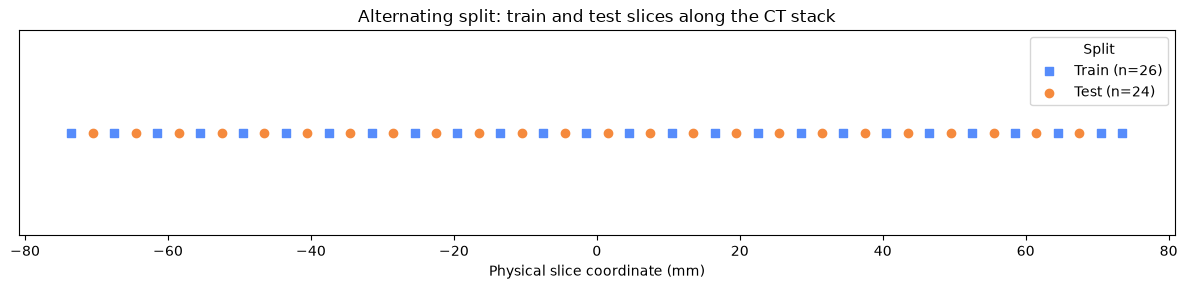

In [31]:
print("Plotting physical slice positions for the train/test split.")


def plot_split(manifest: pd.DataFrame) -> None:
    """Plot physical slice positions with train/test membership."""

    train_rows = manifest[manifest["Split"] == "train"]
    test_rows = manifest[manifest["Split"] == "test"]

    plt.figure(figsize=(12, 3))

    plt.scatter(
        train_rows["SliceCoordinate"],
        np.zeros(len(train_rows)),
        marker="s",
        label=f"Train (n={len(train_rows)})",
    )

    plt.scatter(
        test_rows["SliceCoordinate"],
        np.zeros(len(test_rows)),
        marker="o",
        label=f"Test (n={len(test_rows)})",
    )

    plt.yticks([])
    plt.xlabel("Physical slice coordinate (mm)")
    plt.title("Alternating split: train and test slices along the CT stack")
    plt.legend(title="Split")
    plt.tight_layout()
    plt.show()


plot_split(split_manifest_df)

## 9. Interactive CT slice browser

The browser uses the fixed HU window defined for the working case and displays the train/test assignment for each slice.

In [28]:
print("Creating an interactive browser for the ordered and split CT stack.")


def read_hu_image(path: Path) -> np.ndarray:
    """Read one CT image and convert stored values to Hounsfield units."""

    dataset = pydicom.dcmread(str(path), force=True)
    pixels = dataset.pixel_array.astype(np.float32)
    slope = float(getattr(dataset, "RescaleSlope", 1.0))
    intercept = float(getattr(dataset, "RescaleIntercept", 0.0))
    return pixels * slope + intercept


def window_hu(
        image_hu: np.ndarray,
        low: float,
        high: float,
) -> np.ndarray:
    """Clip HU values to one fixed window and normalize to [0, 1]."""

    if high <= low:
        raise ValueError("HU_WINDOW_HIGH must exceed HU_WINDOW_LOW.")

    clipped = np.clip(image_hu, low, high)
    return (clipped - low) / (high - low)


def show_slice(slice_index: int) -> None:
    """Display one ordered CT slice with its experiment metadata."""

    row = split_manifest_df.iloc[slice_index]
    image = window_hu(
        read_hu_image(Path(row["Path"])),
        HU_WINDOW_LOW,
        HU_WINDOW_HIGH,
    )

    plt.figure(figsize=(7, 7))
    plt.imshow(image, cmap="gray", vmin=0.0, vmax=1.0)
    plt.title(
        f"Slice {slice_index} | {row['Split']} | "
        f"coordinate={row['SliceCoordinate']:.3f} mm | "
        f"HU [{HU_WINDOW_LOW:g}, {HU_WINDOW_HIGH:g}]"
    )
    plt.axis("off")
    plt.tight_layout()
    plt.show()


widgets.interact(
    show_slice,
    slice_index=widgets.IntSlider(
        value=len(split_manifest_df) // 2,
        min=0,
        max=len(split_manifest_df) - 1,
        step=1,
        description="Slice",
        continuous_update=False,
    ),
)

Creating an interactive browser for the ordered and split CT stack.


interactive(children=(IntSlider(value=25, continuous_update=False, description='Slice', max=49), Output()), _d…

<function __main__.show_slice(slice_index: 'int') -> 'None'>

## 10. Export preparation artifacts

In [35]:
print("Saving the prepared case configuration and train/test manifest.")


case_directory = CASES_ROOT / CASE_NAME / resolved_case_name
case_directory.mkdir(parents=True, exist_ok=True)

series_relative_path = selected_series_dir.relative_to(DICOM_ROOT)

case_config = {
    "schema_version": 1,
    "config_name": CASE_NAME,
    "resolved_case_name": resolved_case_name,
    "patient_id": PATIENT_ID,
    "study_date": str(selected_series["StudyDate"]),
    "study_description": str(selected_series["StudyDescription"]),
    "study_instance_uid": selected_study_uid,
    "series_number": int(selected_series["SeriesNumber"]),
    "series_description": str(selected_series["SeriesDescription"]),
    "series_instance_uid": selected_series_uid,
    "series_relative_path": str(series_relative_path),
    "phase_percent": float(TARGET_PHASE_PERCENT),
    "hu_window_low": float(HU_WINDOW_LOW),
    "hu_window_high": float(HU_WINDOW_HIGH),
    "slice_count": int(len(split_manifest_df)),
    "train_slice_count": int(
        (split_manifest_df["Split"] == "train").sum()
    ),
    "test_slice_count": int(
        (split_manifest_df["Split"] == "test").sum()
    ),
    "manifest_file": "split_manifest.csv",
}

manifest_to_save = split_manifest_df[
    [
        "SliceIndex",
        "Split",
        "Path",
        "File",
        "SOPInstanceUID",
        "SliceCoordinate",
        "LowerTrainCoordinate",
        "UpperTrainCoordinate",
    ]
].copy()

manifest_to_save["DICOMRelativePath"] = manifest_to_save["Path"].map(
    lambda value: str(Path(value).relative_to(DICOM_ROOT))
)

manifest_to_save = manifest_to_save[
    [
        "SliceIndex",
        "Split",
        "DICOMRelativePath",
        "File",
        "SOPInstanceUID",
        "SliceCoordinate",
        "LowerTrainCoordinate",
        "UpperTrainCoordinate",
    ]
]

config_path = case_directory / "case.json"
manifest_path = case_directory / "split_manifest.csv"

with config_path.open("w", encoding="utf-8") as handle:
    json.dump(case_config, handle, indent=2, sort_keys=True)
    handle.write("\n")

manifest_to_save.to_csv(manifest_path, index=False)

print(f"Case name:     {resolved_case_name}")
print(f"Configuration: {config_path}")
print(f"Manifest:      {manifest_path}")
print(
    f"Slices:        {case_config['slice_count']} "
    f"(train={case_config['train_slice_count']}, "
    f"test={case_config['test_slice_count']})"
)

Saving the prepared case configuration and train/test manifest.
Case name:     single_phase_ct_every_second_slice_v1__112_HM10395__phase_20__series_036286623964
Configuration: /net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/results/prepared_cases/single_phase_ct_every_second_slice_v1/single_phase_ct_every_second_slice_v1__112_HM10395__phase_20__series_036286623964/case.json
Manifest:      /net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/results/prepared_cases/single_phase_ct_every_second_slice_v1/single_phase_ct_every_second_slice_v1__112_HM10395__phase_20__series_036286623964/split_manifest.csv
Slices:        50 (train=26, test=24)


## 11. Choose case and read back the confog

In [40]:
print("Listing all prepared experiment configurations.")

if not CASES_ROOT.is_dir():
    raise FileNotFoundError(
        f"Prepared cases directory not found: {CASES_ROOT}"
    )

configuration_rows = []

for config_directory in sorted(
    path for path in CASES_ROOT.iterdir() if path.is_dir()
):
    case_files = sorted(config_directory.glob("*/case.json"))

    if not case_files:
        continue

    cases = []

    for case_file in case_files:
        with case_file.open("r", encoding="utf-8") as handle:
            cases.append(json.load(handle))

    config_names = {
        case["config_name"]
        for case in cases
    }

    if config_names != {config_directory.name}:
        raise RuntimeError(
            f"Inconsistent config names in {config_directory}"
        )

    patients = sorted({
        case["patient_id"]
        for case in cases
    })

    phases = sorted({
        float(case["phase_percent"])
        for case in cases
    })

    configuration_rows.append(
        {
            "ConfigName": config_directory.name,
            "PreparedCases": len(cases),
            "Patients": len(patients),
            "Phases": ", ".join(
                f"{phase:g}%"
                for phase in phases
            ),
            "TotalTrainSlices": sum(
                int(case["train_slice_count"])
                for case in cases
            ),
            "TotalTestSlices": sum(
                int(case["test_slice_count"])
                for case in cases
            ),
            "Directory": str(config_directory),
        }
    )

if not configuration_rows:
    raise RuntimeError(
        f"No prepared experiment configurations found in {CASES_ROOT}"
    )

prepared_configurations_df = (
    pd.DataFrame(configuration_rows)
    .sort_values("ConfigName")
    .reset_index(drop=True)
)

print(
    f"Prepared experiment configurations: "
    f"{len(prepared_configurations_df)}"
)

display(prepared_configurations_df)

Listing all prepared experiment configurations.
Prepared experiment configurations: 1


,ConfigName,PreparedCases,Patients,Phases,TotalTrainSlices,TotalTestSlices,Directory
0,single_phase_ct_every_second_slice_v1,1,1,20%,26,24,/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/results/prepared_cases/single_phase_ct_every_second_slice_v1


In [41]:
CONFIG_NAME = "single_phase_ct_every_second_slice_v1"

print("Listing all prepared cases for the selected experiment configuration.")

CONFIG_NAME = "single_phase_ct_every_second_slice_v1"

config_directory = CASES_ROOT / CONFIG_NAME

if not config_directory.is_dir():
    raise FileNotFoundError(
        f"No prepared cases found for configuration: {CONFIG_NAME}"
    )

case_rows = []

for config_path in sorted(config_directory.glob("*/case.json")):
    with config_path.open("r", encoding="utf-8") as handle:
        config = json.load(handle)

    case_rows.append(
        {
            "CaseName": config["resolved_case_name"],
            "PatientID": config["patient_id"],
            "StudyDate": config["study_date"],
            "PhasePercent": config["phase_percent"],
            "Slices": config["slice_count"],
            "Train": config["train_slice_count"],
            "Test": config["test_slice_count"],
            "SeriesDescription": config["series_description"],
            "CaseDirectory": str(config_path.parent),
        }
    )

if not case_rows:
    raise RuntimeError(
        f"No case.json files found in {config_directory}"
    )

prepared_cases_df = (
    pd.DataFrame(case_rows)
    .sort_values(
        ["PatientID", "StudyDate", "PhasePercent", "CaseName"]
    )
    .reset_index(drop=True)
)

print(
    f"Prepared cases for configuration "
    f"{CONFIG_NAME}: {len(prepared_cases_df)}"
)

display(prepared_cases_df)

Listing all prepared cases for the selected experiment configuration.
Prepared cases for configuration single_phase_ct_every_second_slice_v1: 1


,CaseName,PatientID,StudyDate,PhasePercent,Slices,Train,Test,SeriesDescription,CaseDirectory
0,single_phase_ct_every_second_slice_v1__112_HM10395__phase_20__series_036286623964,112_HM10395,19991207,20.0,50,26,24,"P4^P112^S121^I0, Gated, 20.0%",/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/results/prepared_cases/single_phase_ct_every_second_slice_v1/si...


In [42]:
SELECTED_CASE_NAME = (
    "single_phase_ct_every_second_slice_v1"
    "__112_HM10395"
    "__phase_20"
    "__series_036286623964"
)

In [43]:
print("Loading one prepared case for training and evaluation.")

CONFIG_NAME = "single_phase_ct_every_second_slice_v1"

SELECTED_CASE_NAME = (
    "single_phase_ct_every_second_slice_v1"
    "__112_HM10395"
    "__phase_20"
    "__series_036286623964"
)

selected_case_directory = (
    CASES_ROOT
    / CONFIG_NAME
    / SELECTED_CASE_NAME
)

config_path = selected_case_directory / "case.json"

if not config_path.is_file():
    raise FileNotFoundError(
        f"Case configuration not found: {config_path}"
    )

with config_path.open("r", encoding="utf-8") as handle:
    loaded_case_config = json.load(handle)

if loaded_case_config["config_name"] != CONFIG_NAME:
    raise RuntimeError(
        "Loaded configuration name does not match CONFIG_NAME."
    )

if loaded_case_config["resolved_case_name"] != SELECTED_CASE_NAME:
    raise RuntimeError(
        "Loaded case name does not match SELECTED_CASE_NAME."
    )

manifest_path = (
    selected_case_directory
    / loaded_case_config["manifest_file"]
)

if not manifest_path.is_file():
    raise FileNotFoundError(
        f"Split manifest not found: {manifest_path}"
    )

split_manifest_df = pd.read_csv(manifest_path)

required_columns = {
    "SliceIndex",
    "Split",
    "DICOMRelativePath",
    "SOPInstanceUID",
    "SliceCoordinate",
}

missing_columns = required_columns - set(split_manifest_df.columns)

if missing_columns:
    raise RuntimeError(
        f"Manifest is missing columns: {sorted(missing_columns)}"
    )

split_manifest_df["Path"] = split_manifest_df[
    "DICOMRelativePath"
].map(
    lambda value: str(DICOM_ROOT / value)
)

missing_dicom_files = [
    path
    for path in split_manifest_df["Path"]
    if not Path(path).is_file()
]

if missing_dicom_files:
    raise FileNotFoundError(
        f"Missing DICOM file: {missing_dicom_files[0]}"
    )

CASE_NAME = loaded_case_config["config_name"]
resolved_case_name = loaded_case_config["resolved_case_name"]

PATIENT_ID = loaded_case_config["patient_id"]
TARGET_PHASE_PERCENT = float(
    loaded_case_config["phase_percent"]
)

HU_WINDOW_LOW = float(
    loaded_case_config["hu_window_low"]
)
HU_WINDOW_HIGH = float(
    loaded_case_config["hu_window_high"]
)

selected_study_uid = loaded_case_config[
    "study_instance_uid"
]
selected_series_uid = loaded_case_config[
    "series_instance_uid"
]

selected_series_dir = (
    DICOM_ROOT
    / loaded_case_config["series_relative_path"]
)

train_manifest_df = (
    split_manifest_df.loc[
        split_manifest_df["Split"] == "train"
    ]
    .sort_values("SliceIndex")
    .reset_index(drop=True)
)

test_manifest_df = (
    split_manifest_df.loc[
        split_manifest_df["Split"] == "test"
    ]
    .sort_values("SliceIndex")
    .reset_index(drop=True)
)

if len(train_manifest_df) != loaded_case_config["train_slice_count"]:
    raise RuntimeError(
        "Loaded train split size differs from case.json."
    )

if len(test_manifest_df) != loaded_case_config["test_slice_count"]:
    raise RuntimeError(
        "Loaded test split size differs from case.json."
    )

print(f"Case name:         {resolved_case_name}")
print(f"Patient ID:        {PATIENT_ID}")
print(f"Study date:        {loaded_case_config['study_date']}")
print(f"Study UID:         {selected_study_uid}")
print(f"Series UID:        {selected_series_uid}")
print(f"Respiratory phase: {TARGET_PHASE_PERCENT:g}%")
print(
    f"HU window:         "
    f"[{HU_WINDOW_LOW:g}, {HU_WINDOW_HIGH:g}]"
)
print(f"Train slices:      {len(train_manifest_df)}")
print(f"Test slices:       {len(test_manifest_df)}")
print(f"Series directory:  {selected_series_dir}")

display(
    pd.DataFrame(
        [
            {
                "CaseName": resolved_case_name,
                "PatientID": PATIENT_ID,
                "StudyDate": loaded_case_config["study_date"],
                "PhasePercent": TARGET_PHASE_PERCENT,
                "TrainSlices": len(train_manifest_df),
                "TestSlices": len(test_manifest_df),
                "HUWindow": (
                    f"[{HU_WINDOW_LOW:g}, "
                    f"{HU_WINDOW_HIGH:g}]"
                ),
            }
        ]
    )
)

Loading one prepared case for training and evaluation.
Case name:         single_phase_ct_every_second_slice_v1__112_HM10395__phase_20__series_036286623964
Patient ID:        112_HM10395
Study date:        19991207
Study UID:         1.3.6.1.4.1.14519.5.2.1.6834.5010.204802741624618752298023624863
Series UID:        1.3.6.1.4.1.14519.5.2.1.6834.5010.569896177987482348036286623964
Respiratory phase: 20%
HU window:         [-1000, 400]
Train slices:      26
Test slices:       24
Series directory:  /net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d/data/raw/dicom_by_series/112_HM10395/1.3.6.1.4.1.14519.5.2.1.6834.5010.569896177987482348036286623964


,CaseName,PatientID,StudyDate,PhasePercent,TrainSlices,TestSlices,HUWindow
0,single_phase_ct_every_second_slice_v1__112_HM10395__phase_20__series_036286623964,112_HM10395,19991207,20.0,26,24,"[-1000, 400]"
